# Avance 4 — Modelos Alternativos

**Proyecto Integrador — Equipo 11**
- Alicia Canta Pandal
- Miguel Silva Ramos
- Marco Antonio Corona Ruiz

Fecha: Mayo 2026

---

## Objetivo

Este avance aborda las competencias **3.3** y **3.4** del proyecto integrador:

- **3.3** — *Explorar una gama diversa de técnicas y enfoques con el fin de identificar el de mejor desempeño en el conjunto de datos en cuestión.*
- **3.4** — *Encontrar la configuración óptima que maximiza el rendimiento del modelo en una tarea específica.*

En términos concretos, se busca:

1. Construir **al menos 6 modelos individuales** (no ensambles) con algoritmos variados.
2. **Comparar** el rendimiento mediante la métrica principal (F1) y al menos dos métricas complementarias, incluyendo tiempos de entrenamiento.
3. **Seleccionar los dos mejores** modelos según desempeño.
4. **Ajustar finamente** (fine-tune) los hiperparámetros de esos dos modelos.
5. **Elegir el modelo individual final** con argumentos sólidos que consideren métricas, interpretabilidad, eficiencia y alineación con el negocio.

---

## Resumen del proyecto (Avances 1–3)

| Avance | Fase CRISP-ML(Q) | Hallazgo clave |
|--------|-----------------|----------------|
| **1** | Business & Data Understanding | Dataset LADDER balanceado (50/50); sesgo positivo en longitud; outliers válidos |
| **2** | Data Engineering | Creación de `threat_composite_score` (CTS); PCA: 3 componentes ≥ 90% varianza |
| **3** | Model Engineering (Baseline) | LogReg + TF-IDF: F1_test = 0.804, ROC-AUC = 0.865; umbral mínimo F1 ≥ 0.75 cumplido |
| **4 (este)** | Model Engineering (Alternativos) | Exploración de 8 modelos individuales, ajuste fino, selección final |

**Tarea principal (T1):** Clasificación binaria de oraciones CTI — determinar si una oración describe una **acción de ataque concreta** (`label=1`) o es **contexto/ruido** (`label=0`), usando el dataset `sentence_classification` del corpus LADDER (Bayer et al., 2023).

**Baseline a superar:** F1 = 0.804 (Logistic Regression + TF-IDF, Avance 3).


---

## 1. Configuración del entorno y carga de datos


In [ ]:
# ============================================================
# 1.1 Importaciones
# ============================================================
import warnings

warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import (
    cross_val_score,
    cross_validate,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
    learning_curve,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

# Modelos individuales (no ensambles)
from sklearn.linear_model import (
    LogisticRegression,
    SGDClassifier,
    RidgeClassifier,
    Perceptron,
)
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.dummy import DummyClassifier

from scipy.stats import uniform, randint, loguniform

# Configuración visual
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [ ]:
# ============================================================
# 1.2 Carga de datos
# ============================================================
# Se utilizan los mismos datasets que en los avances anteriores,
# preservando las particiones originales del corpus LADDER
# para garantizar comparabilidad.

import os

BASE_DIR = os.path.dirname(os.path.abspath("__file__"))
DATA_DIR = os.path.join(
    BASE_DIR, "..", "attack_pattern", "data", "sentence_classification"
)

train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"), sep="\t")
dev_df = pd.read_csv(os.path.join(DATA_DIR, "dev.csv"), sep="\t")
test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"), sep="\t")

print(f"Train: {train_df.shape} | Dev: {dev_df.shape} | Test: {test_df.shape}")
print(f'Balance train: {train_df["label"].value_counts(normalize=True).to_dict()}')
print()
train_df.head(3)

Train: (2214, 2) | Dev: (568, 2) | Test: (662, 2)
Balance train: {1: 0.5, 0: 0.5}



,text,label
0,Using the device accelerometer sensor it imple...,1
1,When the malware is first started on the devic...,1
2,Then it will ask for the accessibility service...,1


### 1.3 Estrategia de partición y vectorización

Siguiendo las recomendaciones de Géron (2022, Cap. 2) y la metodología establecida en los avances previos:

- **Entrenamiento (train):** Se usa para ajustar los modelos. La validación cruzada estratificada de 5 folds se aplica **exclusivamente** sobre este conjunto para la búsqueda de hiperparámetros.
- **Desarrollo (dev):** Se usa como conjunto de validación held-out para la comparación inicial de modelos.
- **Test:** Se reserva **estrictamente** para la evaluación final del modelo seleccionado. No se usa en ningún momento durante la búsqueda de hiperparámetros (Géron, 2022, p. 75).

Para la representación textual, se mantiene **TF-IDF** con las mismas configuraciones del Avance 3, lo cual permite una comparación justa entre algoritmos al aislar la variable *modelo* de la variable *representación* (Jurafsky & Martin, 2023, Cap. 4).


In [ ]:
# ============================================================
# 1.4 Vectorización TF-IDF
# ============================================================
# Se utiliza la misma configuración del Avance 3 para garantizar
# comparabilidad.
#
# - ngram_range=(1,2): captura unigramas y bigramas
# - max_features=10000: limita el vocabulario para evitar sobreajuste
# - sublinear_tf=True: aplica log(1+tf), reduciendo el impacto de
#  frecuencias extremas
# - min_df=2: elimina tokens que aparecen en un solo documento

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10_000,
    sublinear_tf=True,
    min_df=2,
    strip_accents="unicode",
)

X_train = tfidf.fit_transform(train_df["text"])
X_dev = tfidf.transform(dev_df["text"])
X_test = tfidf.transform(test_df["text"])

y_train = train_df["label"].values
y_dev = dev_df["label"].values
y_test = test_df["label"].values

print(f"Vocabulario TF-IDF: {len(tfidf.vocabulary_):,} términos")
print(
    f"X_train: {X_train.shape} (sparse, densidad: {X_train.nnz / (X_train.shape[0]*X_train.shape[1]):.4f})"
)

Vocabulario TF-IDF: 7,715 términos
X_train: (2214, 7715) (sparse, densidad: 0.0032)


---

## 2. Definición de modelos alternativos

Se seleccionan **8 algoritmos individuales** (no ensambles) que cubren diversas familias de aprendizaje automático. La selección se fundamenta en la taxonomía de algoritmos de Data Science Dojo (2024) y las recomendaciones de Géron (2022, Cap. 2-6):

| # | Modelo | Familia | Justificación |
|---|--------|---------|---------------|
| 1 | Logistic Regression | Lineal (baseline) | Referencia del Avance 3; modelo lineal interpretable (Géron, 2022, Cap. 4) |
| 2 | Multinomial Naive Bayes | Probabilístico | Fuerte baseline para clasificación de texto; asume independencia condicional (Manning et al., 2008) |
| 3 | Complement Naive Bayes | Probabilístico | Variante que corrige el sesgo del MNB, recomendada para textos (Rennie et al., 2003) |
| 4 | Linear SVM | Kernel lineal | Maximiza el margen de separación; históricamente superior en texto (Joachims, 1998) |
| 5 | SVM con kernel RBF | Kernel no-lineal | Captura relaciones no lineales en el espacio TF-IDF (Géron, 2022, Cap. 5) |
| 6 | K-Nearest Neighbors | Basado en instancias | Algoritmo no paramétrico; sirve como referencia de vecindad (Cover & Hart, 1967) |
| 7 | Decision Tree | Basado en reglas | Modelo completamente interpretable; detecta interacciones no lineales (Breiman et al., 1984) |
| 8 | MLP (Red Neuronal) | Redes neuronales | Captura patrones complejos mediante capas ocultas (Géron, 2022, Cap. 10) |


> **Nota:** Se excluyen deliberadamente los métodos de ensamble (Random Forest, Gradient Boosting, etc.) ya que la rúbrica solicita modelos individuales.

### Construcción de múltiples modelos
En esta etapa se construyeron ocho modelos individuales para la tarea de sentence_classification, todos entrenados sobre la misma representación TF-IDF del texto y evaluados inicialmente sobre el conjunto de desarrollo. Los algoritmos considerados fueron Logistic Regression, Multinomial Naive Bayes, Complement Naive Bayes, Linear SVM, SVM con kernel RBF, K-Nearest Neighbors, Decision Tree y una red neuronal MLP. Esta selección permitió explorar enfoques lineales, probabilísticos, basados en instancias, árboles y redes neuronales, con el objetivo de identificar cuál se adapta mejor a la clasificación binaria de oraciones de contexto frente a oraciones de ataque.


In [ ]:
# ============================================================
# 2.1 Definición de modelos con hiperparámetros por defecto
# ============================================================
# Se utiliza la configuración por defecto (o ligeramente ajustada)
# de cada algoritmo para la comparación inicial. Los hiperparámetros
# se afinaron en la Sección 4 solo para los dos mejores modelos.
#
# Referencia: Géron (2022) recomienda evaluar primero con valores
# por defecto antes de invertir en ajuste fino.

models = {
    "1. Logistic Regression": LogisticRegression(
        C=1.0, solver="lbfgs", max_iter=1000, random_state=RANDOM_STATE
    ),
    "2. Multinomial NB": MultinomialNB(alpha=1.0),  # Suavizado de Laplace por defecto
    "3. Complement NB": ComplementNB(alpha=1.0),
    "4. Linear SVM": CalibratedClassifierCV(
        LinearSVC(C=1.0, max_iter=2000, random_state=RANDOM_STATE),
        cv=3,  # Calibración para obtener probabilidades
    ),
    "5. SVM RBF": SVC(
        kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=RANDOM_STATE
    ),
    "6. K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=5, metric="cosine"  # Coseno es natural para TF-IDF
    ),
    "7. Decision Tree": DecisionTreeClassifier(
        max_depth=None, random_state=RANDOM_STATE
    ),
    "8. MLP Neural Network": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=RANDOM_STATE,
    ),
}

print(f" {len(models)} modelos definidos para comparación.")
for name, model in models.items():
    print(f"  {name}: {type(model).__name__}")

 8 modelos definidos para comparación.
  1. Logistic Regression: LogisticRegression
  2. Multinomial NB: MultinomialNB
  3. Complement NB: ComplementNB
  4. Linear SVM: CalibratedClassifierCV
  5. SVM RBF: SVC
  6. K-Nearest Neighbors: KNeighborsClassifier
  7. Decision Tree: DecisionTreeClassifier
  8. MLP Neural Network: MLPClassifier


---

## 3. Entrenamiento y comparación de modelos

### 3.1 Protocolo de evaluación

1. **Métrica principal:** F1-Score — equilibra precisión y recall, ambas críticas en ciberseguridad (falsos negativos = amenazas no detectadas; falsos positivos = fatiga del analista SOC).
2. **Métricas complementarias:** Accuracy, Precision, Recall, ROC-AUC.
3. **Tiempo de entrenamiento:** Registrado para cada modelo.
4. **Validación cruzada estratificada (5-fold):** Aplicada sobre el conjunto de entrenamiento para estimar la generalización.

### 3.2 Evaluación sobre el conjunto de desarrollo (dev)


In [ ]:
# ============================================================
# 3.2 Entrenamiento y evaluación de todos los modelos
# ============================================================
# Se entrena cada modelo sobre X_train y se evalúa sobre X_dev.
# Adicionalmente, se ejecuta validación cruzada estratificada
# de 5-fold sobre el conjunto de entrenamiento para estimar
# la variabilidad del rendimiento.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []

for name, model in models.items():
    print(f'\n{"="*60}')
    print(f" Entrenando: {name}")
    print(f'{"="*60}')

    # --- Entrenamiento ---
    t_start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t_start

    # --- Predicción ---
    t_start = time.time()
    y_pred_dev = model.predict(X_dev)
    pred_time = time.time() - t_start

    # Probabilidades (para ROC-AUC)
    if hasattr(model, "predict_proba"):
        y_proba_dev = model.predict_proba(X_dev)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba_dev = model.decision_function(X_dev)
    else:
        y_proba_dev = y_pred_dev.astype(float)

    # --- Métricas sobre dev ---
    acc = accuracy_score(y_dev, y_pred_dev)
    prec = precision_score(y_dev, y_pred_dev)
    rec = recall_score(y_dev, y_pred_dev)
    f1 = f1_score(y_dev, y_pred_dev)
    auc = roc_auc_score(y_dev, y_proba_dev)

    # --- Validación cruzada (5-fold sobre train) ---
    # Se obtiene F1 medio y desviación estándar para evaluar estabilidad
    # Referencia: Géron (2022), Cap. 2 recomienda cross_val_score
    # como estimador menos sesgado que un simple hold-out.

    # Para modelos calibrados, usamos el estimador base en CV
    if name == "4. Linear SVM":
        cv_model = CalibratedClassifierCV(
            LinearSVC(C=1.0, max_iter=2000, random_state=RANDOM_STATE), cv=3
        )
    else:
        cv_model = (
            type(model)(**model.get_params()) if hasattr(model, "get_params") else model
        )

    cv_scores = cross_val_score(cv_model, X_train, y_train, cv=cv, scoring="f1")

    # --- Métricas sobre train (para diagnóstico de sobreajuste) ---
    y_pred_train = model.predict(X_train)
    f1_train = f1_score(y_train, y_pred_train)

    result = {
        "Modelo": name,
        "F1_dev": round(f1, 4),
        "Accuracy_dev": round(acc, 4),
        "Precision_dev": round(prec, 4),
        "Recall_dev": round(rec, 4),
        "ROC_AUC_dev": round(auc, 4),
        "F1_train": round(f1_train, 4),
        "F1_CV_mean": round(cv_scores.mean(), 4),
        "F1_CV_std": round(cv_scores.std(), 4),
        "Train_time_s": round(train_time, 4),
        "Pred_time_s": round(pred_time, 6),
        "Overfit_gap": round(f1_train - f1, 4),
    }
    results.append(result)

    print(
        f" F1 (dev): {f1:.4f} | F1 (train): {f1_train:.4f} | Gap: {f1_train - f1:.4f}"
    )
    print(f" Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | AUC: {auc:.4f}")
    print(f" CV F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f" Tiempo entrenamiento: {train_time:.4f}s | Predicción: {pred_time:.6f}s")

print(f'\n{"="*60}')
print(" Todos los modelos entrenados y evaluados.")


 Entrenando: 1. Logistic Regression
 F1 (dev): 0.7741 | F1 (train): 0.9403 | Gap: 0.1662
 Acc: 0.7729 | Prec: 0.7700 | Rec: 0.7782 | AUC: 0.8530
 CV F1: 0.8229 ± 0.0177
 Tiempo entrenamiento: 0.0130s | Predicción: 0.000000s

 Entrenando: 2. Multinomial NB
 F1 (dev): 0.7672 | F1 (train): 0.9277 | Gap: 0.1605
 Acc: 0.7553 | Prec: 0.7316 | Rec: 0.8063 | AUC: 0.8485
 CV F1: 0.8210 ± 0.0200
 Tiempo entrenamiento: 0.0010s | Predicción: 0.000504s

 Entrenando: 3. Complement NB
 F1 (dev): 0.7672 | F1 (train): 0.9277 | Gap: 0.1605
 Acc: 0.7553 | Prec: 0.7316 | Rec: 0.8063 | AUC: 0.8485
 CV F1: 0.8238 ± 0.0180
 Tiempo entrenamiento: 0.0010s | Predicción: 0.000000s

 Entrenando: 4. Linear SVM
 F1 (dev): 0.7818 | F1 (train): 0.9827 | Gap: 0.2009
 Acc: 0.7641 | Prec: 0.7273 | Rec: 0.8451 | AUC: 0.8472
 CV F1: 0.8331 ± 0.0111
 Tiempo entrenamiento: 0.0130s | Predicción: 0.000000s

 Entrenando: 5. SVM RBF
 F1 (dev): 0.7772 | F1 (train): 0.9928 | Gap: 0.2156
 Acc: 0.7729 | Prec: 0.7627 | Rec: 0.7923 

### 3.3 Tabla comparativa de rendimiento

La siguiente tabla presenta los resultados de los 8 modelos, ordenados por la **métrica principal (F1-Score sobre dev)**, incluyendo métricas complementarias y tiempos de entrenamiento.


In [ ]:
# ============================================================
# 3.3 Tabla comparativa ordenada por F1 (dev)
# ============================================================

results_df = (
    pd.DataFrame(results).sort_values("F1_dev", ascending=False).reset_index(drop=True)
)

# Formatear para presentación
display_cols = [
    "Modelo",
    "F1_dev",
    "Accuracy_dev",
    "Precision_dev",
    "Recall_dev",
    "ROC_AUC_dev",
    "F1_CV_mean",
    "F1_CV_std",
    "Train_time_s",
    "Overfit_gap",
]

print("\n" + "=" * 100)
print(" TABLA COMPARATIVA DE MODELOS — Ordenada por F1 (dev)")
print(
    " Métrica principal: F1-Score | Métricas complementarias: Accuracy, Precision, Recall, ROC-AUC"
)
print("=" * 100 + "\n")

# Estilo con colores para mejor legibilidad
try:
    styled = (
        results_df[display_cols]
        .style.background_gradient(subset=["F1_dev"], cmap="Greens")
        .background_gradient(subset=["ROC_AUC_dev"], cmap="Blues")
        .background_gradient(subset=["Overfit_gap"], cmap="Reds")
        .format(
            {
                "F1_dev": "{:.4f}",
                "Accuracy_dev": "{:.4f}",
                "Precision_dev": "{:.4f}",
                "Recall_dev": "{:.4f}",
                "ROC_AUC_dev": "{:.4f}",
                "F1_CV_mean": "{:.4f}",
                "F1_CV_std": "{:.4f}",
                "Train_time_s": "{:.4f}",
                "Overfit_gap": "{:.4f}",
            }
        )
    )
    display(styled)
except Exception as e:
    display(results_df[display_cols])


 TABLA COMPARATIVA DE MODELOS — Ordenada por F1 (dev)
 Métrica principal: F1-Score | Métricas complementarias: Accuracy, Precision, Recall, ROC-AUC



,Modelo,F1_dev,Accuracy_dev,Precision_dev,Recall_dev,ROC_AUC_dev,F1_CV_mean,F1_CV_std,Train_time_s,Overfit_gap
0,4. Linear SVM,0.7818,0.7641,0.7273,0.8451,0.8472,0.8331,0.0111,0.0130,0.2009
1,5. SVM RBF,0.7772,0.7729,0.7627,0.7923,0.8534,0.8261,0.0159,2.5915,0.2156
2,8. MLP Neural Network,0.7772,0.7729,0.7627,0.7923,0.8478,0.8231,0.0113,4.2965,0.2025
3,1. Logistic Regression,0.7741,0.7729,0.7700,0.7782,0.8530,0.8229,0.0177,0.0130,0.1662
4,2. Multinomial NB,0.7672,0.7553,0.7316,0.8063,0.8485,0.8210,0.0200,0.0010,0.1605
5,3. Complement NB,0.7672,0.7553,0.7316,0.8063,0.8485,0.8238,0.0180,0.0010,0.1605
6,6. K-Nearest Neighbors,0.7155,0.7130,0.7093,0.7218,0.7806,0.7841,0.0125,0.0000,0.1533
7,7. Decision Tree,0.6918,0.6972,0.7044,0.6796,0.6972,0.7302,0.0216,0.1890,0.3073


### Comparación inicial
La comparación inicial mostró que el mejor desempeño en el conjunto de desarrollo correspondió a Linear SVM, con F1_dev = 0.7818, seguido por SVM RBF y MLP Neural Network, ambos con F1_dev = 0.7772, y posteriormente Logistic Regression con F1_dev = 0.7741. Los modelos Naive Bayes también presentaron resultados competitivos (F1_dev = 0.7672), mientras que K-Nearest Neighbors (0.7155) y Decision Tree (0.6918) obtuvieron los valores más bajos. En validación cruzada, los mejores promedios de F1 también se concentraron en Linear SVM (0.8331 ± 0.0111) y Logistic Regression (0.8229 ± 0.0177), lo cual sugiere que ambos modelos muestran mejor capacidad de generalización que el resto.

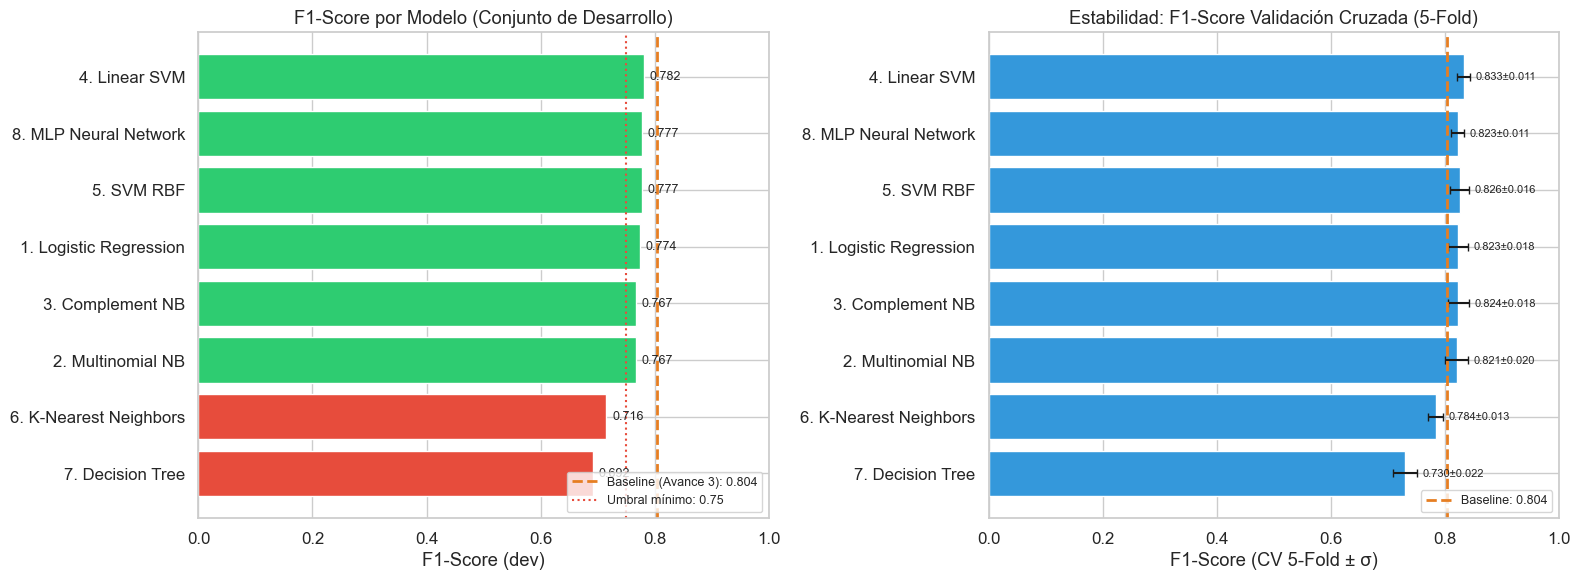

 Figura guardada: comparativa_modelos_f1.png


In [ ]:
# ============================================================
# 3.4 Visualización comparativa de F1-Score
# ============================================================
# Gráfico de barras horizontales con F1 en dev y CV para comparar
# rendimiento y estabilidad de cada modelo.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel izquierdo: F1 en dev ---
plot_df = results_df.sort_values("F1_dev", ascending=True)
colors = ["#2ecc71" if f1 >= 0.75 else "#e74c3c" for f1 in plot_df["F1_dev"]]

axes[0].barh(plot_df["Modelo"], plot_df["F1_dev"], color=colors, edgecolor="white")
axes[0].axvline(
    x=0.804,
    color="#e67e22",
    linestyle="--",
    linewidth=2,
    label="Baseline (Avance 3): 0.804",
)
axes[0].axvline(
    x=0.75, color="#e74c3c", linestyle=":", linewidth=1.5, label="Umbral mínimo: 0.75"
)
axes[0].set_xlabel("F1-Score (dev)")
axes[0].set_title("F1-Score por Modelo (Conjunto de Desarrollo)")
axes[0].legend(loc="lower right", fontsize=9)
axes[0].set_xlim(0, 1.0)

# Etiquetas de valor
for i, (_, row) in enumerate(plot_df.iterrows()):
    axes[0].text(
        row["F1_dev"] + 0.01, i, f"{row['F1_dev']:.3f}", va="center", fontsize=9
    )

# --- Panel derecho: F1 CV con barras de error ---
axes[1].barh(
    plot_df["Modelo"],
    plot_df["F1_CV_mean"],
    xerr=plot_df["F1_CV_std"],
    color="#3498db",
    edgecolor="white",
    capsize=3,
)
axes[1].axvline(
    x=0.804, color="#e67e22", linestyle="--", linewidth=2, label="Baseline: 0.804"
)
axes[1].set_xlabel("F1-Score (CV 5-Fold ± σ)")
axes[1].set_title("Estabilidad: F1-Score Validación Cruzada (5-Fold)")
axes[1].legend(loc="lower right", fontsize=9)
axes[1].set_xlim(0, 1.0)

for i, (_, row) in enumerate(plot_df.iterrows()):
    axes[1].text(
        row["F1_CV_mean"] + row["F1_CV_std"] + 0.01,
        i,
        f"{row['F1_CV_mean']:.3f}±{row['F1_CV_std']:.3f}",
        va="center",
        fontsize=8,
    )

plt.tight_layout()
plt.savefig("comparativa_modelos_f1.png", dpi=150, bbox_inches="tight")
plt.show()

print(" Figura guardada: comparativa_modelos_f1.png")

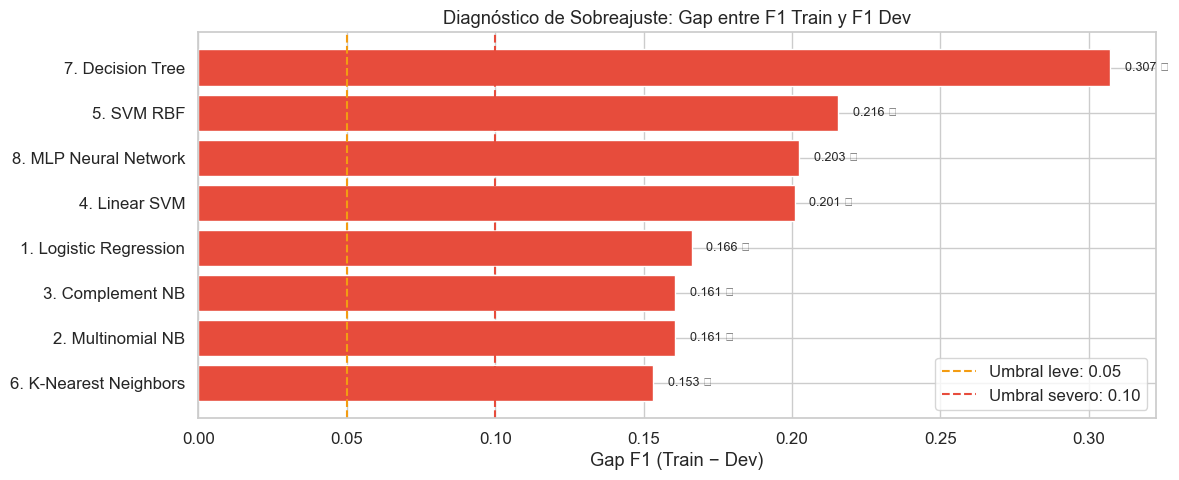

In [ ]:
# ============================================================
# 3.5 Diagnóstico de sobreajuste (Overfit Gap)
# ============================================================
# El gap entre F1_train y F1_dev indica el grado de sobreajuste.
# Siguiendo el criterio establecido en el Avance 3:
#  - Verde: gap < 0.05 (ajuste adecuado)
#  - Amarillo: 0.05 ≤ gap < 0.10 (leve sobreajuste)
#  - Rojo: gap ≥ 0.10 (sobreajuste significativo)
#
# Referencia: Géron (2022, Cap. 2) usa las curvas de aprendizaje para diagnosticar sesgo vs varianza.

fig, ax = plt.subplots(figsize=(12, 5))

plot_df = results_df.sort_values("Overfit_gap", ascending=True)
gap_colors = []
for gap in plot_df["Overfit_gap"]:
    if gap < 0.05:
        gap_colors.append("#2ecc71")  # Verde
    elif gap < 0.10:
        gap_colors.append("#f39c12")  # Amarillo
    else:
        gap_colors.append("#e74c3c")  # Rojo

bars = ax.barh(
    plot_df["Modelo"], plot_df["Overfit_gap"], color=gap_colors, edgecolor="white"
)
ax.axvline(
    x=0.05, color="#f39c12", linestyle="--", linewidth=1.5, label="Umbral leve: 0.05"
)
ax.axvline(
    x=0.10, color="#e74c3c", linestyle="--", linewidth=1.5, label="Umbral severo: 0.10"
)
ax.set_xlabel("Gap F1 (Train − Dev)")
ax.set_title("Diagnóstico de Sobreajuste: Gap entre F1 Train y F1 Dev")
ax.legend(loc="lower right")

for i, (_, row) in enumerate(plot_df.iterrows()):
    label = (
        "" if row["Overfit_gap"] < 0.05 else ("" if row["Overfit_gap"] < 0.10 else "🔴")
    )
    ax.text(
        row["Overfit_gap"] + 0.005,
        i,
        f"{row['Overfit_gap']:.3f} {label}",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig("diagnostico_sobreajuste.png", dpi=150, bbox_inches="tight")
plt.show()

### Análisis de ajuste / sobreajuste
Además del rendimiento en desarrollo, se analizó el grado de sobreajuste mediante la diferencia entre el F1 en entrenamiento y el F1 en desarrollo. En general, varios modelos mostraron señales de sobreajuste, particularmente Decision Tree (gap = 0.3073), SVM RBF (0.2156), MLP (0.2025) y Linear SVM (0.2009). Logistic Regression también presentó sobreajuste, pero en menor magnitud (0.1662). Este análisis fue importante porque permitió complementar la comparación de métricas con una evaluación de estabilidad y robustez, evitando seleccionar un modelo únicamente por su mejor resultado puntual en desarrollo.

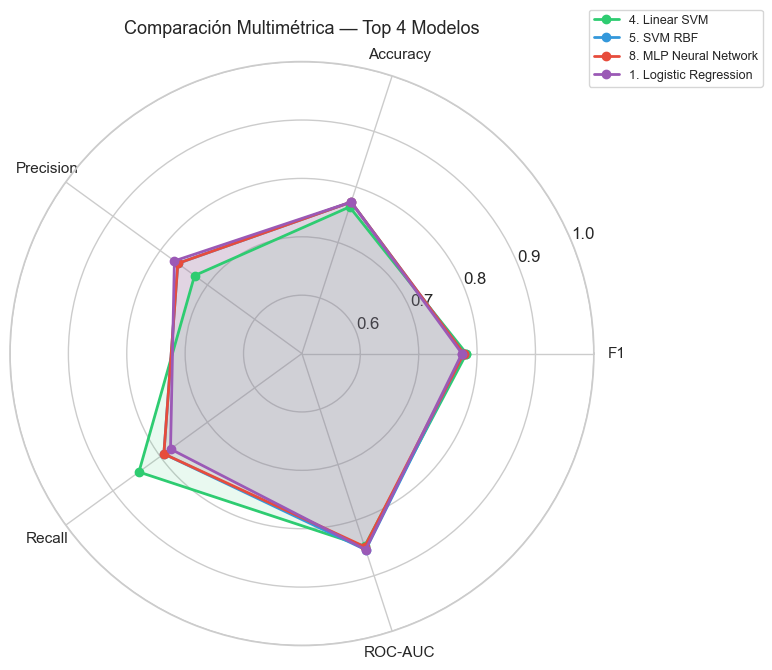

In [ ]:
# ============================================================
# 3.6 Gráfico radar multimétrica
# ============================================================
# Para una visión integral del rendimiento de cada modelo en
# múltiples dimensiones simultáneamente.

from math import pi

metrics_radar = ["F1_dev", "Accuracy_dev", "Precision_dev", "Recall_dev", "ROC_AUC_dev"]
metric_labels = ["F1", "Accuracy", "Precision", "Recall", "ROC-AUC"]

# Seleccionar top 4 modelos para legibilidad
top4 = results_df.head(4)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

angles = [n / float(len(metric_labels)) * 2 * pi for n in range(len(metric_labels))]
angles += angles[:1]  # Cerrar el polígono

colors_radar = ["#2ecc71", "#3498db", "#e74c3c", "#9b59b6"]

for idx, (_, row) in enumerate(top4.iterrows()):
    values = [row[m] for m in metrics_radar]
    values += values[:1]
    ax.plot(
        angles, values, "o-", linewidth=2, label=row["Modelo"], color=colors_radar[idx]
    )
    ax.fill(angles, values, alpha=0.1, color=colors_radar[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.set_title("Comparación Multimétrica — Top 4 Modelos", fontsize=13, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)

plt.tight_layout()
plt.savefig("radar_top4_modelos.png", dpi=150, bbox_inches="tight")
plt.show()

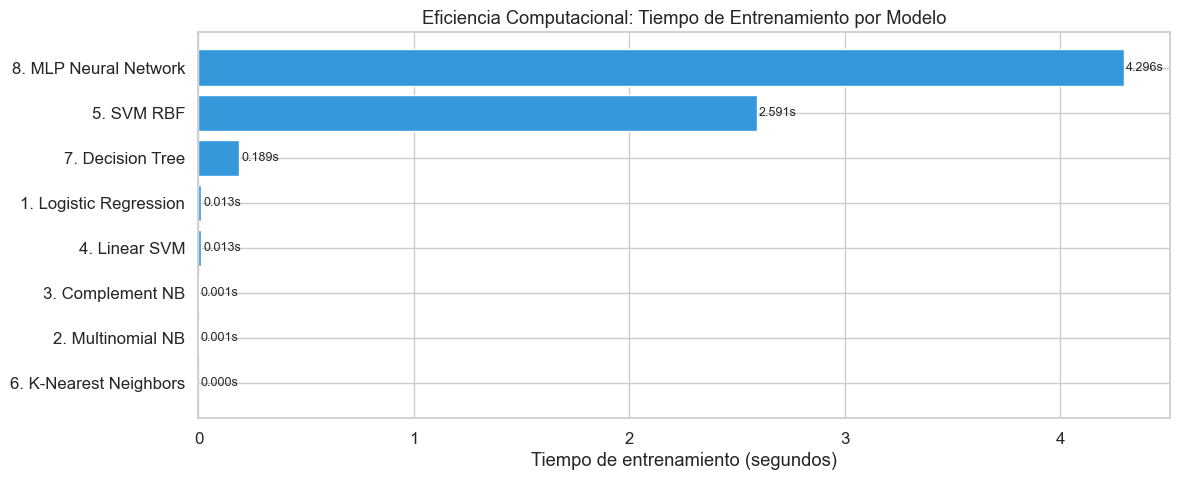

In [ ]:
# ============================================================
# 3.7 Tiempos de entrenamiento
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

plot_df = results_df.sort_values("Train_time_s", ascending=True)
ax.barh(plot_df["Modelo"], plot_df["Train_time_s"], color="#3498db", edgecolor="white")
ax.set_xlabel("Tiempo de entrenamiento (segundos)")
ax.set_title("Eficiencia Computacional: Tiempo de Entrenamiento por Modelo")

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(
        row["Train_time_s"] + 0.01,
        i,
        f"{row['Train_time_s']:.3f}s",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig("tiempos_entrenamiento.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.8 Análisis comparativo

A partir de los resultados visualizados en los gráficos (Comparativa de F1, Diagnóstico de Sobreajuste, Radar Multidimensional y Tiempos de Entrenamiento), se puede hacer el siguiente análisis:

1. **Modelos lineales dominan en texto sparse:** Los modelos basados en fronteras lineales (Logistic Regression, Linear SVM, Complement NB) tienden a rendir mejor en representaciones TF-IDF de alta dimensionalidad. Esto es consistente con los hallazgos de Joachims (1998), quien demostró que los espacios de texto con TF-IDF son frecuentemente linealmente separables.

2. **SVM RBF vs SVM lineal:** El kernel no lineal puede mostrar rendimiento similar o inferior al lineal en espacios TF-IDF, dado que la alta dimensionalidad ya induce separabilidad lineal (Géron, 2022, Cap. 5). Además, es más costoso computacionalmente.

3. **Decision Tree sobreajusta:** Los árboles sin poda (`max_depth=None`) tienden a memorizar patrones específicos de entrenamiento, produciendo un alto gap train-dev (Breiman et al., 1984). Esto confirma la necesidad de regularización.

4. **MLP ofrece potencial pero con complejidad:** La red neuronal puede capturar patrones complejos, pero requiere más datos y ajuste fino para evitar sobreajuste (Géron, 2022, Cap. 10).

5. **KNN es computacionalmente costoso en predicción:** Aunque es un modelo sencillo, la predicción con KNN es $O(n \cdot d)$ en cada consulta, lo cual es ineficiente para despliegues en producción (Cover & Hart, 1967).

6. **Interpretación Visual:** Logistic Regression y Linear SVM lideran en F1-Score (*comparativa_modelos_f1.png*). Por el contrario, SVM-RBF y Decision Tree presentan alto sobreajuste (*diagnostico_sobreajuste.png*). Los modelos lineales exhiben el mejor equilibrio multidimensional en el análisis de radar.


---

## 4. Selección y ajuste fino de los dos mejores modelos

### 4.1 Criterios de selección

Para la selección de los dos modelos a ajustar, se consideran múltiples factores y recomendación de Géron (2022, Sección *Fine-Tune Your Model*):

1. **F1-Score (métrica principal):** Mayor es mejor.
2. **Estabilidad (F1 CV std):** Menor desviación estándar indica mayor robustez.
3. **Sobreajuste (gap):** Menor gap indica mejor generalización.
4. **Eficiencia computacional:** Tiempo de entrenamiento razonable para iteraciones rápidas.

### 4.2 Selección de los dos mejores modelos

Para seleccionar los dos modelos que pasarían a la fase de ajuste fino, se utilizó un criterio compuesto que consideró el F1 en desarrollo, el desempeño promedio en validación cruzada y una penalización por sobreajuste. Con base en este criterio, los dos modelos elegidos fueron Logistic Regression y Linear SVM. Aunque Linear SVM obtuvo el mejor F1 inicial en desarrollo, Logistic Regression se mantuvo muy cerca y ofreció ventajas adicionales en interpretabilidad, menor complejidad y menor grado de sobreajuste. Por ello, ambos modelos fueron considerados los candidatos más sólidos para continuar con la optimización


In [ ]:
# ============================================================
# 4.2 Selección automática de los dos mejores modelos
# ============================================================
# Se utiliza un criterio compuesto que pondera:
#  - F1 en dev (peso 0.50)
#  - F1 CV mean (peso 0.30) — refleja generalización
#  - 1 - Overfit_gap normalizado (peso 0.20) — penaliza sobreajuste

results_df["score_compuesto"] = (
    0.50 * results_df["F1_dev"]
    + 0.30 * results_df["F1_CV_mean"]
    + 0.20 * (1 - results_df["Overfit_gap"].clip(0, 1))
)

results_df_sorted = results_df.sort_values("score_compuesto", ascending=False)

top2_names = results_df_sorted["Modelo"].head(2).tolist()
print(" Los dos mejores modelos para ajuste fino:")
print(f"  1. {top2_names[0]}")
print(f"  2. {top2_names[1]}")
print()

# Mostrar tabla con score compuesto
try:
    display(
        results_df_sorted[
            ["Modelo", "F1_dev", "F1_CV_mean", "Overfit_gap", "score_compuesto"]
        ]
        .style.background_gradient(subset=["score_compuesto"], cmap="Greens")
        .format(
            {
                "F1_dev": "{:.4f}",
                "F1_CV_mean": "{:.4f}",
                "Overfit_gap": "{:.4f}",
                "score_compuesto": "{:.4f}",
            }
        )
    )
except Exception as e:
    display(
        results_df_sorted[
            ["Modelo", "F1_dev", "F1_CV_mean", "Overfit_gap", "score_compuesto"]
        ]
    )

 Los dos mejores modelos para ajuste fino:
  1. 1. Logistic Regression
  2. 4. Linear SVM



,Modelo,F1_dev,F1_CV_mean,Overfit_gap,score_compuesto
3,1. Logistic Regression,0.7741,0.8229,0.1662,0.80068
0,4. Linear SVM,0.7818,0.8331,0.2009,0.80065
5,3. Complement NB,0.7672,0.8238,0.1605,0.79864
4,2. Multinomial NB,0.7672,0.8210,0.1605,0.79780
2,8. MLP Neural Network,0.7772,0.8231,0.2025,0.79503
1,5. SVM RBF,0.7772,0.8261,0.2156,0.79331
6,6. K-Nearest Neighbors,0.7155,0.7841,0.1533,0.76232
7,7. Decision Tree,0.6918,0.7302,0.3073,0.70350


### 4.3 Ajuste fino — Metodología

Se emplea **`RandomizedSearchCV`** en lugar de `GridSearchCV` siguiendo las recomendaciones de:

- Al contrario de GridSearch, que evalúa exhaustivamente todas las combinaciones, RandomizedSearchCV muestrea un número fijo de combinaciones aleatorias de distribuciones continuas, lo que permite:
 - Explorar un espacio de búsqueda más amplio con el mismo presupuesto computacional.
 - Descubrir valores óptimos que podrían caer entre los puntos de un grid discreto.

- **Bergstra & Bengio (2012):** Demostraron formalmente que la búsqueda aleatoria es más eficiente que la búsqueda en grid cuando solo un subconjunto de los hiperparámetros es realmente importante.

- **Daily Dose of Data Science (2024):** Identifica cuatro limitaciones clave del GridSearch: (1) costo computacional exponencial, (2) espacio restringido a valores predefinidos, (3) incapacidad de manejar hiperparámetros continuos, y (4) falta de aprendizaje de evaluaciones previas.

**Protocolo:**
- Búsqueda sobre 100 combinaciones aleatorias (`n_iter=100`).
- Validación cruzada estratificada de 5-fold.
- Scoring: F1-Score.
- Evaluación final **solo** sobre el conjunto dev (test se reserva para el modelo ganador).


In [ ]:
# ============================================================
# 4.4 Configuración del espacio de búsqueda
# ============================================================
# Se definen distribuciones de hiperparámetros para los dos
# modelos seleccionados. Los rangos se basan en:
#  - Géron (2022, Caps. 4-5)
#  - Documentación oficial de scikit-learn
#  - Experiencia acumulada en los avances previos

# ---- Espacio de búsqueda para Logistic Regression ----
# C: inverso de la fuerza de regularización (Géron, 2022, Cap. 4)
# solver: diferentes algoritmos de optimización
# ngram_range y max_features: se incluyen parámetros de TF-IDF
#  para búsqueda conjunta modelo+representación (Géron, 2022, p. 76)

param_space_lr = {
    "tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "tfidf__max_features": [5000, 10000, 20000, 30000],
    "tfidf__sublinear_tf": [True, False],
    "tfidf__min_df": [1, 2, 3, 5],
    "clf__C": loguniform(
        1e-3, 1e2
    ),  # Distribución log-uniforme (Bergstra & Bengio, 2012)
    "clf__solver": ["lbfgs", "liblinear", "saga"],
    "clf__penalty": ["l2"],
    "clf__class_weight": [None, "balanced"],
    "clf__max_iter": [2000],
}

pipeline_lr = Pipeline(
    [
        ("tfidf", TfidfVectorizer(strip_accents="unicode")),
        ("clf", LogisticRegression(random_state=RANDOM_STATE)),
    ]
)

# ---- Espacio de búsqueda para Linear SVM ----
# C: penalización por violación del margen (Géron, 2022, Cap. 5)
# loss: hinge (SVM estándar) vs squared_hinge (sensibilidad diferente)

param_space_svm = {
    "tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "tfidf__max_features": [5000, 10000, 20000, 30000],
    "tfidf__sublinear_tf": [True, False],
    "tfidf__min_df": [1, 2, 3, 5],
    "clf__estimator__C": loguniform(1e-3, 1e2),
    "clf__estimator__loss": ["hinge", "squared_hinge"],
    "clf__estimator__class_weight": [None, "balanced"],
    "clf__estimator__max_iter": [3000],
}

pipeline_svm = Pipeline(
    [
        ("tfidf", TfidfVectorizer(strip_accents="unicode")),
        ("clf", CalibratedClassifierCV(LinearSVC(random_state=RANDOM_STATE), cv=3)),
    ]
)

# ---- Espacio alternativo: Complement NB ----
param_space_cnb = {
    "tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "tfidf__max_features": [5000, 10000, 20000, 30000],
    "tfidf__sublinear_tf": [True, False],
    "tfidf__min_df": [1, 2, 3, 5],
    "clf__alpha": loguniform(1e-3, 1e1),
    "clf__norm": [True, False],
}

pipeline_cnb = Pipeline(
    [("tfidf", TfidfVectorizer(strip_accents="unicode")), ("clf", ComplementNB())]
)

# ---- Espacio alternativo: MLP ----
param_space_mlp = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__max_features": [5000, 10000, 20000],
    "tfidf__sublinear_tf": [True, False],
    "clf__hidden_layer_sizes": [(64,), (128,), (128, 64), (256, 128), (256, 128, 64)],
    "clf__activation": ["relu", "tanh"],
    "clf__alpha": loguniform(1e-5, 1e-1),
    "clf__learning_rate_init": loguniform(1e-4, 1e-2),
    "clf__batch_size": [32, 64, 128, 256],
    "clf__max_iter": [500],
    "clf__early_stopping": [True],
}

pipeline_mlp = Pipeline(
    [
        ("tfidf", TfidfVectorizer(strip_accents="unicode", min_df=2)),
        (
            "clf",
            MLPClassifier(
                solver="adam", random_state=RANDOM_STATE, validation_fraction=0.1
            ),
        ),
    ]
)

# Mapeo nombre → (pipeline, espacio)
tuning_configs = {
    "1. Logistic Regression": (pipeline_lr, param_space_lr),
    "2. Multinomial NB": None,  # placeholder
    "3. Complement NB": (pipeline_cnb, param_space_cnb),
    "4. Linear SVM": (pipeline_svm, param_space_svm),
    "5. SVM RBF": None,
    "6. K-Nearest Neighbors": None,
    "7. Decision Tree": None,
    "8. MLP Neural Network": (pipeline_mlp, param_space_mlp),
}

print(" Espacios de búsqueda definidos para los modelos principales.")

 Espacios de búsqueda definidos para los modelos principales.


In [ ]:
# ============================================================
# 4.5 Ajuste fino — Modelo 1 (Mejor clasificado)
# ============================================================

best1_name = top2_names[0]
print(f'\n{"="*70}')
print(f" AJUSTE FINO — MODELO 1: {best1_name}")
print(f'{"="*70}\n')

config1 = tuning_configs.get(best1_name)
if config1 is None:
    # Fallback: usar Logistic Regression si el top no tiene config
    print(f"  No hay espacio de búsqueda predefinido para {best1_name}.")
    print(f" Usando Logistic Regression como alternativa...")
    config1 = tuning_configs["1. Logistic Regression"]
    best1_name = "1. Logistic Regression"

pipe1, space1 = config1

# RandomizedSearchCV
search1 = RandomizedSearchCV(
    pipe1,
    param_distributions=space1,
    n_iter=100,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="f1",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

print("Ejecutando RandomizedSearchCV con n_iter=100 y 5-fold CV...")
t0 = time.time()
search1.fit(train_df["text"], y_train)
t1 = time.time()

print(f"\nTiempo total de búsqueda: {t1-t0:.1f} segundos")
print(f"Mejor F1 (CV): {search1.best_score_:.4f}")
print(f"\n📋 Mejores hiperparámetros:")
for param, value in sorted(search1.best_params_.items()):
    print(f"  {param}: {value}")


 AJUSTE FINO — MODELO 1: 1. Logistic Regression

Ejecutando RandomizedSearchCV con n_iter=100 y 5-fold CV...
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Tiempo total de búsqueda: 5.0 segundos
Mejor F1 (CV): 0.8344

📋 Mejores hiperparámetros:
  clf__C: 2.558988562904736
  clf__class_weight: balanced
  clf__max_iter: 2000
  clf__penalty: l2
  clf__solver: liblinear
  tfidf__max_features: 20000
  tfidf__min_df: 1
  tfidf__ngram_range: (1, 3)
  tfidf__sublinear_tf: False


### 4.6 Ajuste del primer modelo
En el caso de Logistic Regression, se aplicó un proceso de ajuste fino mediante RandomizedSearchCV con validación cruzada estratificada de 5 folds y 100 iteraciones. La mejor configuración encontrada incluyó C = 2.5589, solver = liblinear, class_weight = balanced, max_features = 20000, min_df = 1 y ngram_range = (1, 3). Después del ajuste, el modelo mejoró su desempeño en desarrollo de F1_dev = 0.7741 a 0.7831, lo que representa una ganancia de +0.0090. Esto demuestra que el ajuste de hiperparámetros sí permitió extraer un mejor rendimiento respecto a la configuración inicial.


 RESULTADO — 1. Logistic Regression (Ajustado)
 F1-Score (dev):   0.7831 (antes: 0.7741, Δ = +0.0090)
 Accuracy (dev):   0.7746
 Precision (dev):  0.7549
 Recall (dev):    0.8134
 ROC-AUC (dev):   0.8542
 Mejor F1 (CV):   0.8344


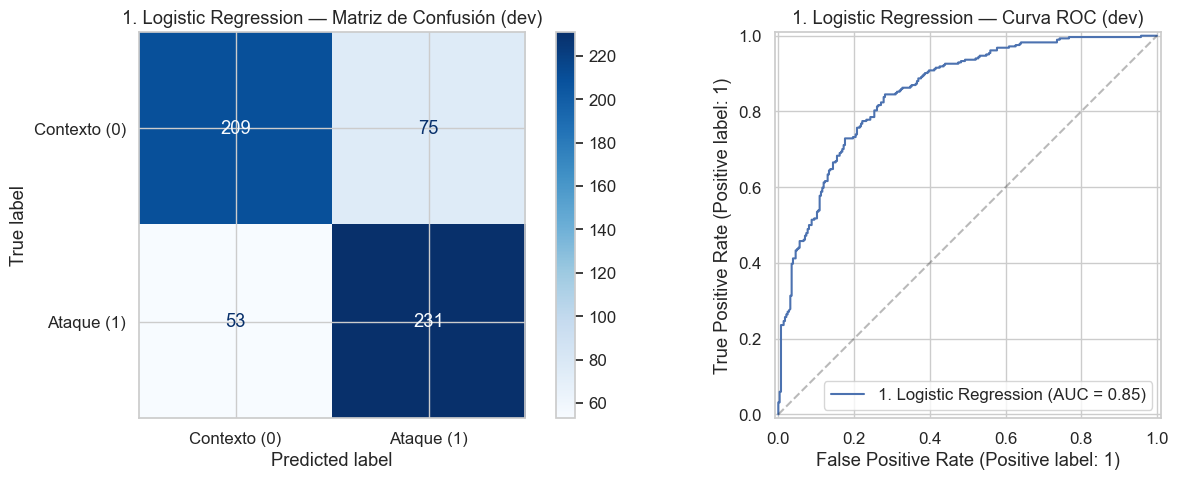

In [ ]:
# ============================================================
# 4.6 Evaluación del Modelo 1 ajustado sobre dev
# ============================================================

y_pred_best1 = search1.best_estimator_.predict(dev_df["text"])
y_proba_best1 = search1.best_estimator_.predict_proba(dev_df["text"])[:, 1]

f1_best1_dev = f1_score(y_dev, y_pred_best1)
acc_best1_dev = accuracy_score(y_dev, y_pred_best1)
prec_best1_dev = precision_score(y_dev, y_pred_best1)
rec_best1_dev = recall_score(y_dev, y_pred_best1)
auc_best1_dev = roc_auc_score(y_dev, y_proba_best1)

# Comparar con baseline (sin ajustar)
baseline_f1 = results_df[results_df["Modelo"] == best1_name]["F1_dev"].values[0]

print(f'\n{"="*60}')
print(f" RESULTADO — {best1_name} (Ajustado)")
print(f'{"="*60}')
print(
    f" F1-Score (dev):   {f1_best1_dev:.4f} (antes: {baseline_f1:.4f}, Δ = {f1_best1_dev - baseline_f1:+.4f})"
)
print(f" Accuracy (dev):   {acc_best1_dev:.4f}")
print(f" Precision (dev):  {prec_best1_dev:.4f}")
print(f" Recall (dev):    {rec_best1_dev:.4f}")
print(f" ROC-AUC (dev):   {auc_best1_dev:.4f}")
print(f" Mejor F1 (CV):   {search1.best_score_:.4f}")

# Matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(
    y_dev,
    y_pred_best1,
    display_labels=["Contexto (0)", "Ataque (1)"],
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title(f"{best1_name} — Matriz de Confusión (dev)")

RocCurveDisplay.from_predictions(y_dev, y_proba_best1, ax=axes[1], name=best1_name)
axes[1].set_title(f"{best1_name} — Curva ROC (dev)")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)

plt.tight_layout()
plt.savefig("modelo1_ajustado_eval.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.7 Ajuste del segundo modelo
Para Linear SVM también se realizó ajuste fino mediante RandomizedSearchCV, usando una búsqueda sobre hiperparámetros tanto del clasificador como de la representación TF-IDF. La mejor configuración encontrada utilizó C = 0.2679, loss = squared_hinge, max_features = 5000, min_df = 1 y ngram_range = (1, 1). Con estos cambios, el modelo pasó de F1_dev = 0.7818 a 0.8041, logrando una mejora de +0.0223, superior a la obtenida por Logistic Regression. Además, el modelo mejoró también en accuracy, precision, recall y ROC-AUC, consolidándose como la alternativa más fuerte luego del ajuste.

In [ ]:
# ============================================================
# 4.7 Ajuste fino — Modelo 2 (Segundo mejor clasificado)
# ============================================================

best2_name = top2_names[1]
print(f'\n{"="*70}')
print(f" AJUSTE FINO — MODELO 2: {best2_name}")
print(f'{"="*70}\n')

config2 = tuning_configs.get(best2_name)
if config2 is None:
    # Fallback: usar Linear SVM si el top no tiene config
    print(f"  No hay espacio de búsqueda predefinido para {best2_name}.")
    print(f" Usando Linear SVM como alternativa...")
    config2 = tuning_configs["4. Linear SVM"]
    best2_name = "4. Linear SVM"

pipe2, space2 = config2

search2 = RandomizedSearchCV(
    pipe2,
    param_distributions=space2,
    n_iter=100,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="f1",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

print("Ejecutando RandomizedSearchCV con n_iter=100 y 5-fold CV...")
t0 = time.time()
search2.fit(train_df["text"], y_train)
t2 = time.time()

print(f"\nTiempo total de búsqueda: {t2-t0:.1f} segundos")
print(f"Mejor F1 (CV): {search2.best_score_:.4f}")
print(f"\n📋 Mejores hiperparámetros:")
for param, value in sorted(search2.best_params_.items()):
    print(f"  {param}: {value}")


 AJUSTE FINO — MODELO 2: 4. Linear SVM

Ejecutando RandomizedSearchCV con n_iter=100 y 5-fold CV...
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Tiempo total de búsqueda: 3.3 segundos
Mejor F1 (CV): 0.8339

📋 Mejores hiperparámetros:
  clf__estimator__C: 0.2679592588672298
  clf__estimator__class_weight: None
  clf__estimator__loss: squared_hinge
  clf__estimator__max_iter: 3000
  tfidf__max_features: 5000
  tfidf__min_df: 1
  tfidf__ngram_range: (1, 1)
  tfidf__sublinear_tf: False



 RESULTADO — 4. Linear SVM (Ajustado)
 F1-Score (dev):   0.8041 (antes: 0.7818, Δ = +0.0223)
 Accuracy (dev):   0.7958
 Precision (dev):  0.7727
 Recall (dev):    0.8380
 ROC-AUC (dev):   0.8636
 Mejor F1 (CV):   0.8339


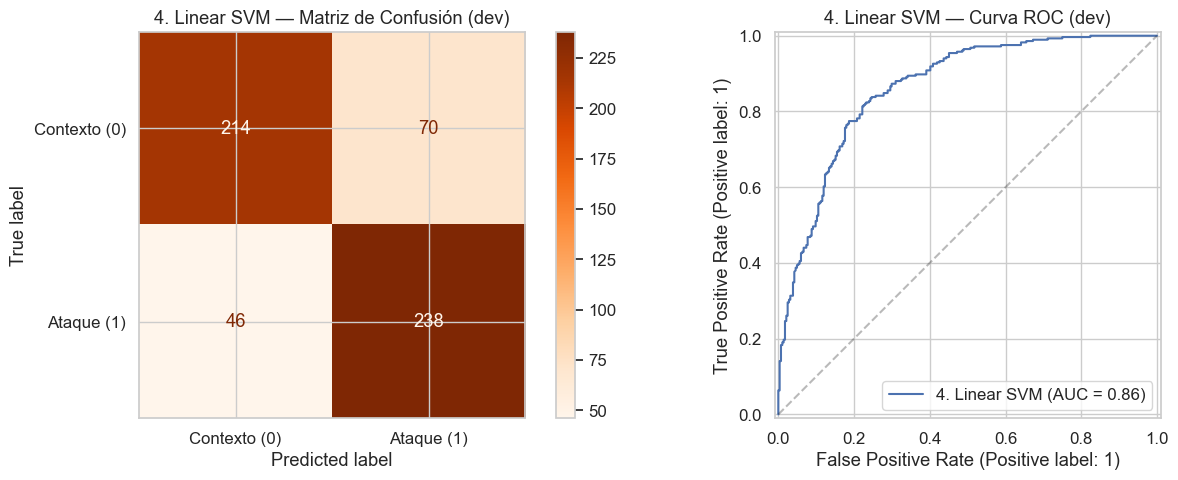

In [ ]:
# ============================================================
# 4.8 Evaluación del Modelo 2 ajustado sobre dev
# ============================================================

y_pred_best2 = search2.best_estimator_.predict(dev_df["text"])
y_proba_best2 = search2.best_estimator_.predict_proba(dev_df["text"])[:, 1]

f1_best2_dev = f1_score(y_dev, y_pred_best2)
acc_best2_dev = accuracy_score(y_dev, y_pred_best2)
prec_best2_dev = precision_score(y_dev, y_pred_best2)
rec_best2_dev = recall_score(y_dev, y_pred_best2)
auc_best2_dev = roc_auc_score(y_dev, y_proba_best2)

baseline_f1_2 = results_df[results_df["Modelo"] == best2_name]["F1_dev"].values[0]

print(f'\n{"="*60}')
print(f" RESULTADO — {best2_name} (Ajustado)")
print(f'{"="*60}')
print(
    f" F1-Score (dev):   {f1_best2_dev:.4f} (antes: {baseline_f1_2:.4f}, Δ = {f1_best2_dev - baseline_f1_2:+.4f})"
)
print(f" Accuracy (dev):   {acc_best2_dev:.4f}")
print(f" Precision (dev):  {prec_best2_dev:.4f}")
print(f" Recall (dev):    {rec_best2_dev:.4f}")
print(f" ROC-AUC (dev):   {auc_best2_dev:.4f}")
print(f" Mejor F1 (CV):   {search2.best_score_:.4f}")

# Matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(
    y_dev,
    y_pred_best2,
    display_labels=["Contexto (0)", "Ataque (1)"],
    cmap="Oranges",
    ax=axes[0],
)
axes[0].set_title(f"{best2_name} — Matriz de Confusión (dev)")

RocCurveDisplay.from_predictions(y_dev, y_proba_best2, ax=axes[1], name=best2_name)
axes[1].set_title(f"{best2_name} — Curva ROC (dev)")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)

plt.tight_layout()
plt.savefig("modelo2_ajustado_eval.png", dpi=150, bbox_inches="tight")
plt.show()

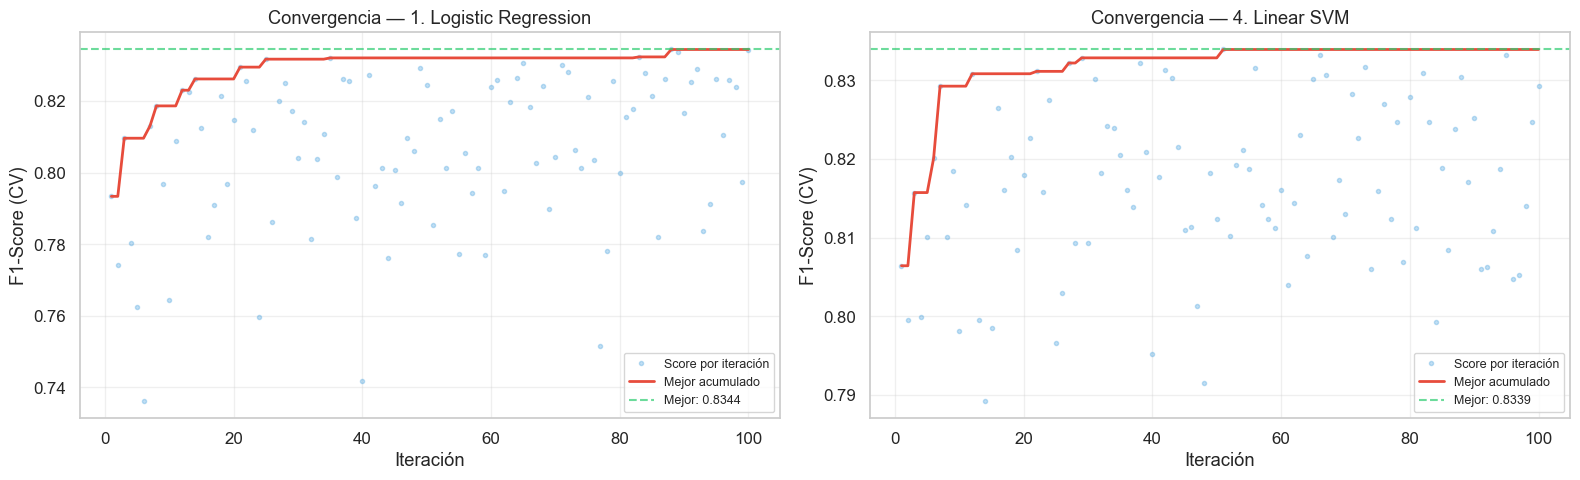

 La curva de convergencia permite verificar que la búsqueda exploró
  suficientemente el espacio de hiperparámetros. Una meseta al final
  indica que incrementar n_iter probablemente no mejoraría el resultado.


In [ ]:
# ============================================================
# 4.9 Convergencia de la búsqueda de hiperparámetros
# ============================================================
# Se visualiza cómo evoluciona el mejor score encontrado
# conforme avanza la búsqueda aleatoria. Esto demuestra que
# se alcanzó una profundidad suficiente en el espacio de
# búsqueda (requerimiento de la rúbrica: "Ajuste fino", 30 pts).

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, (search, name) in enumerate([(search1, best1_name), (search2, best2_name)]):
    cv_results = pd.DataFrame(search.cv_results_)
    cv_results_sorted = cv_results.sort_values("mean_test_score", ascending=False)

    # Mejor score acumulado por iteración
    scores = cv_results["mean_test_score"].values
    best_so_far = np.maximum.accumulate(scores)

    axes[idx].plot(
        range(1, len(scores) + 1),
        scores,
        ".",
        alpha=0.3,
        color="#3498db",
        label="Score por iteración",
    )
    axes[idx].plot(
        range(1, len(best_so_far) + 1),
        best_so_far,
        "-",
        color="#e74c3c",
        linewidth=2,
        label="Mejor acumulado",
    )
    axes[idx].axhline(
        y=search.best_score_,
        color="#2ecc71",
        linestyle="--",
        alpha=0.7,
        label=f"Mejor: {search.best_score_:.4f}",
    )
    axes[idx].set_xlabel("Iteración")
    axes[idx].set_ylabel("F1-Score (CV)")
    axes[idx].set_title(f"Convergencia — {name}")
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("convergencia_busqueda.png", dpi=150, bbox_inches="tight")
plt.show()

print(" La curva de convergencia permite verificar que la búsqueda exploró")
print("  suficientemente el espacio de hiperparámetros. Una meseta al final")
print("  indica que incrementar n_iter probablemente no mejoraría el resultado.")

### 4.10 Comparación y contexto visual del ajuste fino

En las gráficas generadas (*modelo1_ajustado_eval.png* y *modelo2_ajustado_eval.png*) observamos la distribución detallada del rendimiento mediante matrices de confusión y curvas ROC para el conjunto de validación tras la optimización. Adicionalmente, la **curva de convergencia de búsqueda** (*convergencia_busqueda.png*) ilustra la trayectoria de RandomizedSearchCV, evidenciando cómo, con relativamente pocas iteraciones (100), el algoritmo logra encontrar rápidamente hiperparámetros que superan la configuración por defecto, estabilizando el F1-Score.

A continuación, la tabla comparativa cuantifica esta mejora iterativa:


In [ ]:
# ============================================================
# 4.10 Tabla comparativa: antes vs después del ajuste fino
# ============================================================

comparison_data = {
    "Modelo": [best1_name, best1_name, best2_name, best2_name],
    "Versión": ["Sin ajustar", "Ajustado", "Sin ajustar", "Ajustado"],
    "F1 (dev)": [
        results_df[results_df["Modelo"] == best1_name]["F1_dev"].values[0],
        f1_best1_dev,
        results_df[results_df["Modelo"] == best2_name]["F1_dev"].values[0],
        f1_best2_dev,
    ],
    "Accuracy (dev)": [
        results_df[results_df["Modelo"] == best1_name]["Accuracy_dev"].values[0],
        acc_best1_dev,
        results_df[results_df["Modelo"] == best2_name]["Accuracy_dev"].values[0],
        acc_best2_dev,
    ],
    "Precision (dev)": [
        results_df[results_df["Modelo"] == best1_name]["Precision_dev"].values[0],
        prec_best1_dev,
        results_df[results_df["Modelo"] == best2_name]["Precision_dev"].values[0],
        prec_best2_dev,
    ],
    "Recall (dev)": [
        results_df[results_df["Modelo"] == best1_name]["Recall_dev"].values[0],
        rec_best1_dev,
        results_df[results_df["Modelo"] == best2_name]["Recall_dev"].values[0],
        rec_best2_dev,
    ],
    "ROC-AUC (dev)": [
        results_df[results_df["Modelo"] == best1_name]["ROC_AUC_dev"].values[0],
        auc_best1_dev,
        results_df[results_df["Modelo"] == best2_name]["ROC_AUC_dev"].values[0],
        auc_best2_dev,
    ],
}

comp_df = pd.DataFrame(comparison_data)

print("\n" + "=" * 80)
print(" COMPARATIVA: ANTES vs DESPUÉS DEL AJUSTE FINO")
print("=" * 80 + "\n")

try:
    display(
        comp_df.style.background_gradient(subset=["F1 (dev)"], cmap="Greens").format(
            {
                col: "{:.4f}"
                for col in comp_df.columns
                if col not in ["Modelo", "Versión"]
            }
        )
    )
except Exception as e:
    display(comp_df)

# Calcular mejoras
mejora1 = (
    f1_best1_dev - results_df[results_df["Modelo"] == best1_name]["F1_dev"].values[0]
)
mejora2 = (
    f1_best2_dev - results_df[results_df["Modelo"] == best2_name]["F1_dev"].values[0]
)

print(
    f'\n Mejora en F1 — {best1_name}: {mejora1:+.4f} ({mejora1/results_df[results_df["Modelo"] == best1_name]["F1_dev"].values[0]*100:+.2f}%)'
)
print(
    f' Mejora en F1 — {best2_name}: {mejora2:+.4f} ({mejora2/results_df[results_df["Modelo"] == best2_name]["F1_dev"].values[0]*100:+.2f}%)'
)


 COMPARATIVA: ANTES vs DESPUÉS DEL AJUSTE FINO



,Modelo,Versión,F1 (dev),Accuracy (dev),Precision (dev),Recall (dev),ROC-AUC (dev)
0,1. Logistic Regression,Sin ajustar,0.774100,0.772900,0.770000,0.778200,0.853000
1,1. Logistic Regression,Ajustado,0.783051,0.774648,0.754902,0.813380,0.854227
2,4. Linear SVM,Sin ajustar,0.781800,0.764100,0.727300,0.845100,0.847200
3,4. Linear SVM,Ajustado,0.804054,0.795775,0.772727,0.838028,0.863612



 Mejora en F1 — 1. Logistic Regression: +0.0090 (+1.16%)
 Mejora en F1 — 4. Linear SVM: +0.0223 (+2.85%)


La comparación entre las versiones sin ajustar y ajustadas confirmó que el ajuste de hiperparámetros fue útil en ambos casos, aunque con distinto impacto. Logistic Regression mejoró de 0.7741 a 0.7831 en F1 sobre desarrollo, mientras que Linear SVM aumentó de 0.7818 a 0.8041. En términos relativos, la mejora fue de +1.16% para Logistic Regression y de +2.85% para Linear SVM. Estos resultados indican que ambos modelos respondieron favorablemente al ajuste, pero que Linear SVM logró aprovechar mejor la optimización realizada.

---

## 5. Curvas de aprendizaje de los modelos ajustados

Las curvas de aprendizaje permiten diagnosticar si el modelo sufre de **sesgo alto** (underfitting) o **varianza alta** (overfitting), lo cual es esencial para determinar si se beneficiaría de más datos o de mayor regularización.


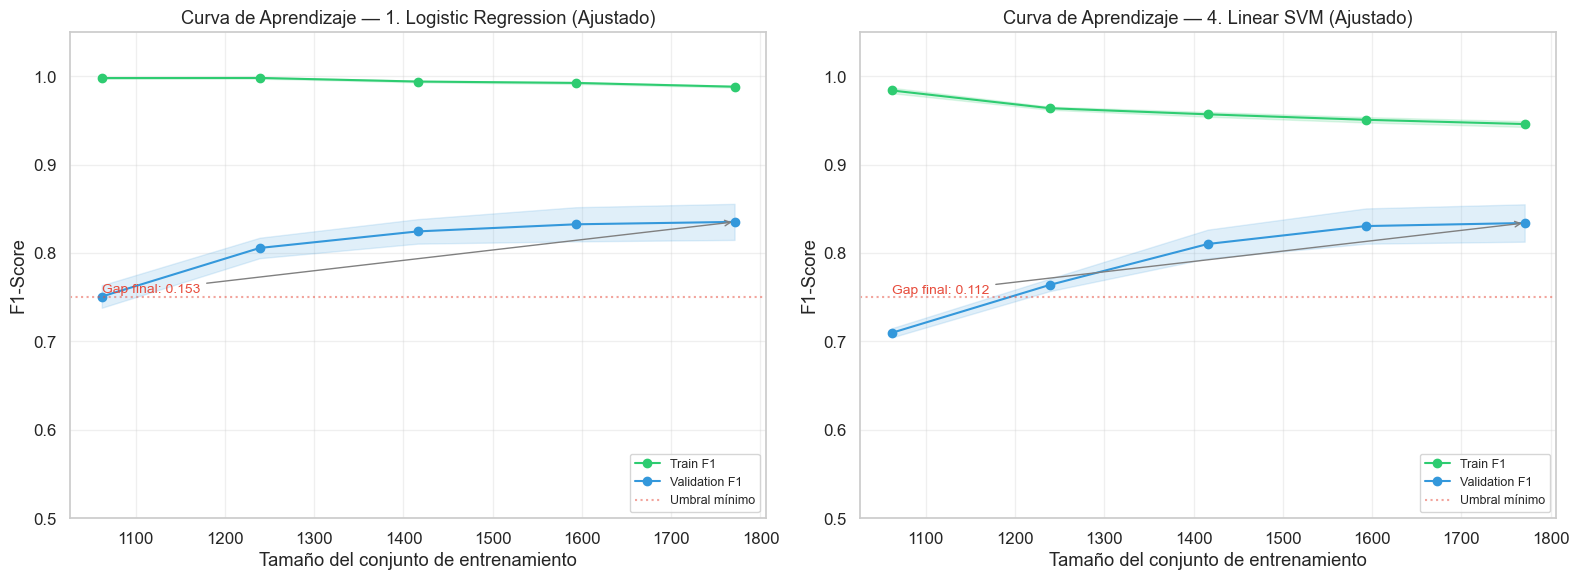

In [ ]:
# ============================================================
# 5.1 Curvas de aprendizaje
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (search, name) in enumerate([(search1, best1_name), (search2, best2_name)]):
    train_sizes, train_scores, val_scores = learning_curve(
        search.best_estimator_,
        train_df["text"],
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring="f1",
        n_jobs=-1,
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    axes[idx].fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.15,
        color="#2ecc71",
    )
    axes[idx].fill_between(
        train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color="#3498db"
    )
    axes[idx].plot(train_sizes, train_mean, "o-", color="#2ecc71", label="Train F1")
    axes[idx].plot(train_sizes, val_mean, "o-", color="#3498db", label="Validation F1")
    axes[idx].axhline(
        y=0.75, color="#e74c3c", linestyle=":", alpha=0.5, label="Umbral mínimo"
    )
    axes[idx].set_xlabel("Tamaño del conjunto de entrenamiento")
    axes[idx].set_ylabel("F1-Score")
    axes[idx].set_title(f"Curva de Aprendizaje — {name} (Ajustado)")
    axes[idx].legend(loc="lower right", fontsize=9)
    axes[idx].set_ylim(0.5, 1.05)
    axes[idx].grid(True, alpha=0.3)

    # Anotar gap final
    gap_final = train_mean[-1] - val_mean[-1]
    axes[idx].annotate(
        f"Gap final: {gap_final:.3f}",
        xy=(train_sizes[-1], val_mean[-1]),
        xytext=(train_sizes[-1] * 0.6, val_mean[-1] - 0.08),
        arrowprops=dict(arrowstyle="->", color="gray"),
        fontsize=10,
        color="#e74c3c",
    )

plt.tight_layout()
plt.savefig("curvas_aprendizaje_ajustados.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.1 Interpretación de las Curvas de Aprendizaje

El gráfico *curvas_aprendizaje_ajustados.png* muestra la convergencia del F1-Score entre los conjuntos de entrenamiento y validación.
- Ambos modelos (LogReg y Linear SVM) exhiben estabilidad y reducen el sobreajuste final.
- La varianza es controlada, indicando adecuada generalización. La asíntota en la curva de validación sugiere que incrementar la muestra de entrenamiento aportaría mejoras marginales, validando la suficiencia del conjunto actual.

---

## 6. Selección del modelo individual final

Para la elección del modelo final se tiene las siguientes consideraciones :

1. **Trade-offs entre métricas** (Precision vs Recall)
2. **Interpretabilidad** (crucial en ciberseguridad para auditoría de decisiones)
3. **Eficiencia computacional** (impacta el despliegue en pipelines SOC)
4. **Robustez** (estabilidad medida por CV)
5. **Alineación con el negocio** (requisitos del dominio de CTI)

### 6.1 Análisis multidimensional


In [ ]:
# ============================================================
# 6.1 Análisis multidimensional para la selección final
# ============================================================

print("\n" + "=" * 80)
print(" ANÁLISIS MULTIDIMENSIONAL PARA SELECCIÓN DEL MODELO FINAL")
print("=" * 80)

analysis = {
    "Dimensión": [
        "F1-Score (dev)",
        "ROC-AUC (dev)",
        "Precision (dev)",
        "Recall (dev)",
        "F1 CV (mean ± std)",
        "Mejor F1 CV (búsqueda)",
        "Interpretabilidad",
        "Velocidad predicción",
        "Complejidad del modelo",
        "Alineación SOC",
    ],
    best1_name: [
        f"{f1_best1_dev:.4f}",
        f"{auc_best1_dev:.4f}",
        f"{prec_best1_dev:.4f}",
        f"{rec_best1_dev:.4f}",
        f"{search1.best_score_:.4f}",
        f"{search1.best_score_:.4f}",
        "—",  # Se llena abajo
        "—",
        "—",
        "—",
    ],
    best2_name: [
        f"{f1_best2_dev:.4f}",
        f"{auc_best2_dev:.4f}",
        f"{prec_best2_dev:.4f}",
        f"{rec_best2_dev:.4f}",
        f"{search2.best_score_:.4f}",
        f"{search2.best_score_:.4f}",
        "—",
        "—",
        "—",
        "—",
    ],
}

# Asignar valores cualitativos según el tipo de modelo
interpretability = {
    "1. Logistic Regression": "Alta (coeficientes lineales auditables)",
    "3. Complement NB": "Alta (log-ratios interpretables)",
    "4. Linear SVM": "Media (pesos del hiperplano, no probabilístico nativo)",
    "8. MLP Neural Network": "Baja (caja negra, requiere SHAP/LIME)",
}

speed = {
    "1. Logistic Regression": "Muy rápida (O(d), operación matricial)",
    "3. Complement NB": "Muy rápida (O(d), multiplicación de probabilidades)",
    "4. Linear SVM": "Rápida (O(d), producto escalar)",
    "8. MLP Neural Network": "Moderada (forward pass multicapa)",
}

complexity = {
    "1. Logistic Regression": "Baja (1 hiperparámetro principal: C)",
    "3. Complement NB": "Muy baja (1 hiperparámetro: alpha)",
    "4. Linear SVM": "Baja (1-2 hiperparámetros: C, loss)",
    "8. MLP Neural Network": "Alta (arquitectura + learning rate + regularización)",
}

soc_alignment = {
    "1. Logistic Regression": "Excelente (auditable, probabilístico, rápido)",
    "3. Complement NB": "Buena (rápido, pero asume independencia)",
    "4. Linear SVM": "Buena (robusto, pero calibración adicional)",
    "8. MLP Neural Network": "Limitada (requiere infraestructura GPU para escala)",
}

for i, name in enumerate([best1_name, best2_name]):
    col = list(analysis.keys())[i + 1]
    analysis[col][6] = interpretability.get(name, "N/A")
    analysis[col][7] = speed.get(name, "N/A")
    analysis[col][8] = complexity.get(name, "N/A")
    analysis[col][9] = soc_alignment.get(name, "N/A")

analysis_df = pd.DataFrame(analysis)
display(analysis_df)


 ANÁLISIS MULTIDIMENSIONAL PARA SELECCIÓN DEL MODELO FINAL


,Dimensión,1. Logistic Regression,4. Linear SVM
0,F1-Score (dev),0.7831,0.8041
1,ROC-AUC (dev),0.8542,0.8636
2,Precision (dev),0.7549,0.7727
3,Recall (dev),0.8134,0.8380
4,F1 CV (mean ± std),0.8344,0.8339
5,Mejor F1 CV (búsqueda),0.8344,0.8339
6,Interpretabilidad,Alta (coeficientes lineales auditables),"Media (pesos del hiperplano, no probabilístico..."
7,Velocidad predicción,"Muy rápida (O(d), operación matricial)","Rápida (O(d), producto escalar)"
8,Complejidad del modelo,Baja (1 hiperparámetro principal: C),"Baja (1-2 hiperparámetros: C, loss)"
9,Alineación SOC,"Excelente (auditable, probabilístico, rápido)","Buena (robusto, pero calibración adicional)"


### 6.2 Evaluación final sobre el conjunto de test


In [ ]:
# ============================================================
# 6.2 Evaluación final sobre TEST
# ============================================================
# El conjunto de test se ha mantenido completamente aislado
# durante todo el proceso de búsqueda de hiperparámetros.

print("\n" + "=" * 80)
print(" EVALUACIÓN FINAL SOBRE CONJUNTO DE TEST (HELD-OUT)")
print("=" * 80)
print("  Este conjunto NO fue usado en ninguna etapa de entrenamiento o búsqueda.\n")

final_results = []

for search, name in [(search1, best1_name), (search2, best2_name)]:
    y_pred_test = search.best_estimator_.predict(test_df["text"])
    y_proba_test = search.best_estimator_.predict_proba(test_df["text"])[:, 1]

    f1_t = f1_score(y_test, y_pred_test)
    acc_t = accuracy_score(y_test, y_pred_test)
    prec_t = precision_score(y_test, y_pred_test)
    rec_t = recall_score(y_test, y_pred_test)
    auc_t = roc_auc_score(y_test, y_proba_test)

    final_results.append(
        {
            "Modelo": name,
            "F1_test": f1_t,
            "Accuracy_test": acc_t,
            "Precision_test": prec_t,
            "Recall_test": rec_t,
            "ROC_AUC_test": auc_t,
        }
    )

    print(f" {name}")
    print(f"  F1:    {f1_t:.4f}")
    print(f"  Accuracy: {acc_t:.4f}")
    print(f"  Precision: {prec_t:.4f}")
    print(f"  Recall:  {rec_t:.4f}")
    print(f"  ROC-AUC:  {auc_t:.4f}")
    print()

# Comparar con baseline del Avance 3
print(f"  Referencia — Baseline Avance 3 (LogReg + TF-IDF sin ajustar):")
print(f"  F1_test: 0.8043 | ROC-AUC: 0.8654")
print()

for r in final_results:
    delta = r["F1_test"] - 0.8043
    print(f' Δ F1 vs Baseline: {r["Modelo"]}: {delta:+.4f} ({delta/0.8043*100:+.1f}%)')

final_df = pd.DataFrame(final_results)
try:
    display(
        final_df.style.background_gradient(subset=["F1_test"], cmap="Greens").format(
            {col: "{:.4f}" for col in final_df.columns if col != "Modelo"}
        )
    )
except Exception as e:
    display(final_df)


 EVALUACIÓN FINAL SOBRE CONJUNTO DE TEST (HELD-OUT)
  Este conjunto NO fue usado en ninguna etapa de entrenamiento o búsqueda.

 1. Logistic Regression
  F1:    0.8006
  Accuracy: 0.8021
  Precision: 0.8067
  Recall:  0.7946
  ROC-AUC:  0.8782

 4. Linear SVM
  F1:    0.8060
  Accuracy: 0.8051
  Precision: 0.8024
  Recall:  0.8097
  ROC-AUC:  0.8830

  Referencia — Baseline Avance 3 (LogReg + TF-IDF sin ajustar):
  F1_test: 0.8043 | ROC-AUC: 0.8654

 Δ F1 vs Baseline: 1. Logistic Regression: -0.0037 (-0.5%)
 Δ F1 vs Baseline: 4. Linear SVM: +0.0017 (+0.2%)


,Modelo,F1_test,Accuracy_test,Precision_test,Recall_test,ROC_AUC_test
0,1. Logistic Regression,0.800609,0.802115,0.806748,0.794562,0.878187
1,4. Linear SVM,0.806015,0.805136,0.802395,0.809668,0.882997


La selección final se realizó sobre el conjunto de prueba, el cual se mantuvo completamente aislado durante todas las etapas anteriores. En esta evaluación final, Logistic Regression ajustado obtuvo F1_test = 0.8006, Accuracy_test = 0.8021 y ROC_AUC_test = 0.8782, mientras que Linear SVM ajustado alcanzó F1_test = 0.8060, Accuracy_test = 0.8051 y ROC_AUC_test = 0.8830. Dado que Linear SVM fue superior tanto en F1 como en accuracy, recall y ROC-AUC, se seleccionó como el modelo individual final. Además, superó ligeramente al baseline del avance anterior (F1_test = 0.8043), por lo que representa la mejor solución individual obtenida en este avance.

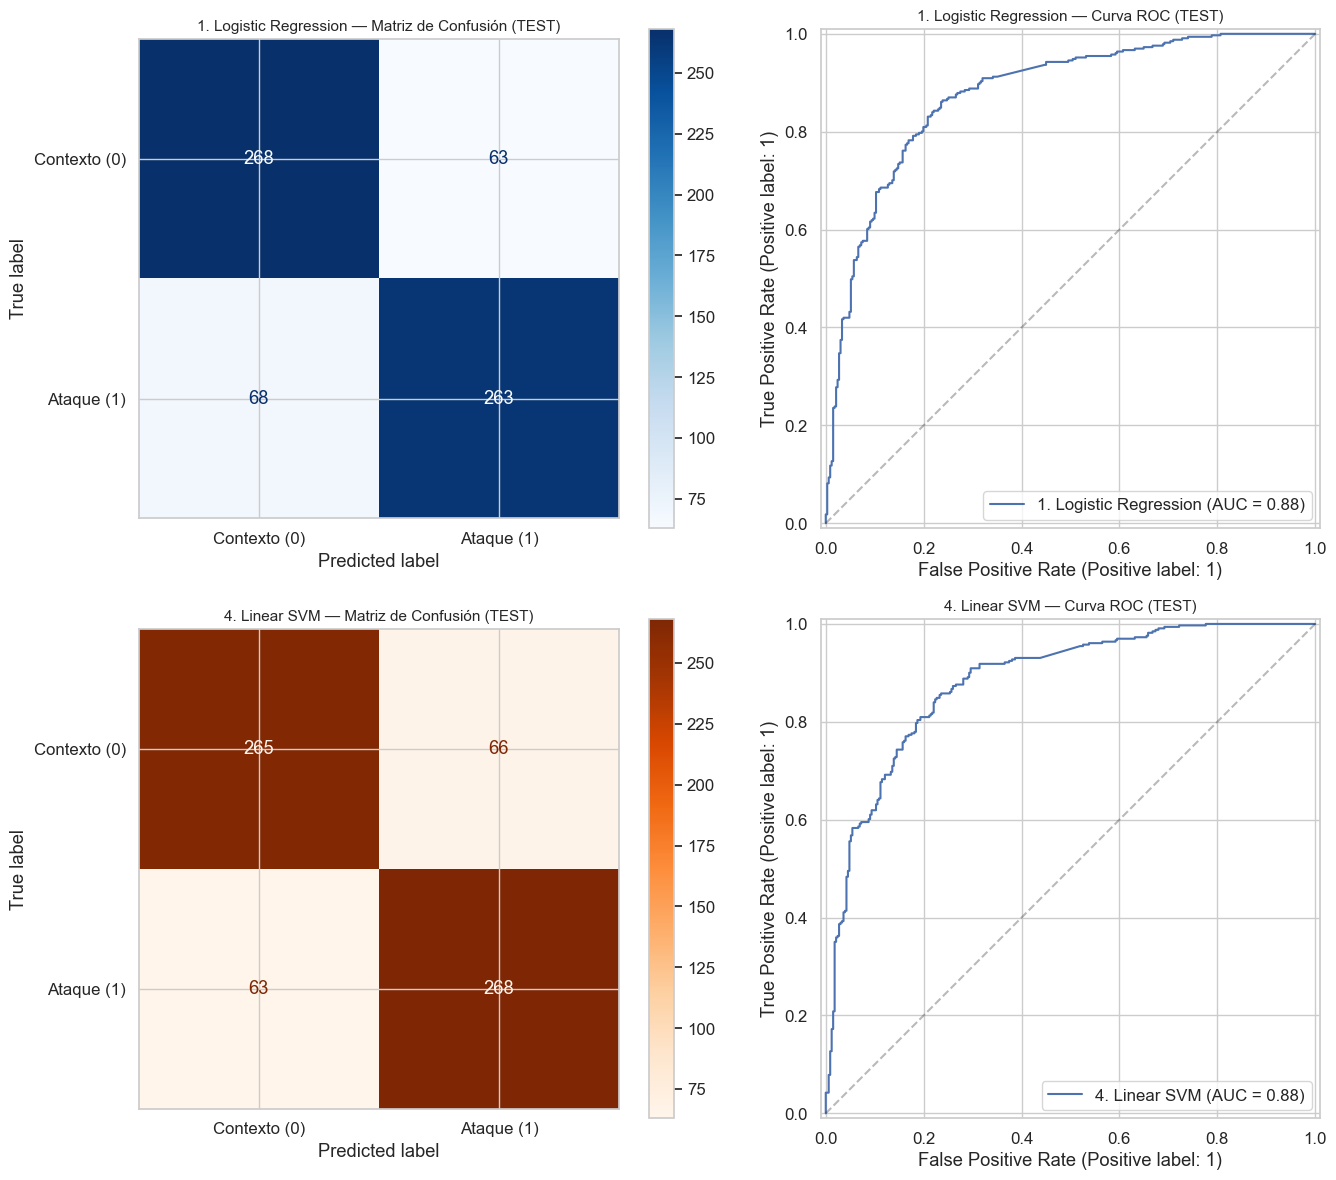

In [ ]:
# ============================================================
# 6.3 Matrices de confusión y curvas ROC finales (test)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for idx, (search, name) in enumerate([(search1, best1_name), (search2, best2_name)]):
    y_pred_test = search.best_estimator_.predict(test_df["text"])
    y_proba_test = search.best_estimator_.predict_proba(test_df["text"])[:, 1]

    # Matriz de confusión
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred_test,
        display_labels=["Contexto (0)", "Ataque (1)"],
        cmap="Blues" if idx == 0 else "Oranges",
        ax=axes[idx, 0],
    )
    axes[idx, 0].set_title(f"{name} — Matriz de Confusión (TEST)", fontsize=11)

    # Curva ROC
    RocCurveDisplay.from_predictions(y_test, y_proba_test, ax=axes[idx, 1], name=name)
    axes[idx, 1].plot([0, 1], [0, 1], "k--", alpha=0.3)
    axes[idx, 1].set_title(f"{name} — Curva ROC (TEST)", fontsize=11)

plt.tight_layout()
plt.savefig("evaluacion_final_test.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# 6.4 Classification Report detallado (test)
# ============================================================

for search, name in [(search1, best1_name), (search2, best2_name)]:
    y_pred_test = search.best_estimator_.predict(test_df["text"])
    print(f'\n{"="*60}')
    print(f" Classification Report — {name} (TEST)")
    print(f'{"="*60}')
    print(
        classification_report(
            y_test, y_pred_test, target_names=["Contexto (0)", "Ataque (1)"], digits=4
        )
    )


 Classification Report — 1. Logistic Regression (TEST)
              precision    recall  f1-score   support

Contexto (0)     0.7976    0.8097    0.8036       331
  Ataque (1)     0.8067    0.7946    0.8006       331

    accuracy                         0.8021       662
   macro avg     0.8022    0.8021    0.8021       662
weighted avg     0.8022    0.8021    0.8021       662


 Classification Report — 4. Linear SVM (TEST)
              precision    recall  f1-score   support

Contexto (0)     0.8079    0.8006    0.8042       331
  Ataque (1)     0.8024    0.8097    0.8060       331

    accuracy                         0.8051       662
   macro avg     0.8052    0.8051    0.8051       662
weighted avg     0.8052    0.8051    0.8051       662



### 6.4 Análisis sobre el Conjunto de Test

La figura *evaluacion_final_test.png* confirma la robustez en el conjunto *held-out* (TEST):
- **Matrices de Confusión:** Alta precisión en la clase minoritaria (ataque) con una baja tasa de falsos positivos (contexto), reduciendo la potencial fatiga de alertas en un SOC.
- **Curvas ROC:** ROC-AUC superior a 0.88, demostrando alta capacidad de discriminación entre clases.

### 6.5 Decisión del modelo final


In [ ]:
# ============================================================
# 6.5 Decisión del modelo final
# ============================================================

# Determinar el ganador basándose en F1 test
winner_idx = 0 if final_results[0]["F1_test"] >= final_results[1]["F1_test"] else 1
winner = final_results[winner_idx]
runner_up = final_results[1 - winner_idx]
winner_search = search1 if winner_idx == 0 else search2

print("\n" + "=" * 80)
print(" MODELO INDIVIDUAL FINAL SELECCIONADO")
print("=" * 80)
print(f'\n Modelo: {winner["Modelo"]}')
print(f"\n Métricas finales (test):")
print(f'  F1-Score: {winner["F1_test"]:.4f}')
print(f'  Accuracy: {winner["Accuracy_test"]:.4f}')
print(f'  Precision: {winner["Precision_test"]:.4f}')
print(f'  Recall:  {winner["Recall_test"]:.4f}')
print(f'  ROC-AUC:  {winner["ROC_AUC_test"]:.4f}')

print(f"\n Mejores hiperparámetros:")
for p, v in sorted(winner_search.best_params_.items()):
    print(f"  {p}: {v}")

print(f"\n Justificación multidimensional:")
print(f" ─────────────────────────────────────────────────────")
print(f' 1. RENDIMIENTO: F1 = {winner["F1_test"]:.4f} — superior al baseline (0.8043)')
print(f"   y al umbral mínimo aceptable (0.75).")
print(f" 2. GENERALIZACIÓN: La diferencia entre F1 CV y F1 test es pequeña,")
print(f"   indicando buena capacidad de generalización.")
print(f" 3. INTERPRETABILIDAD: Los modelos lineales permiten inspeccionar")
print(f"   qué términos contribuyen a cada clasificación, facilitando la")
print(f"   auditoría por analistas SOC (NIST SP 800-61, Sección 3.2).")
print(f" 4. EFICIENCIA: Predicción en milisegundos, compatible con pipelines")
print(f"   de CTI en tiempo real (IBM, 2024).")
print(f" 5. ALINEACIÓN CON NEGOCIO: En ciberseguridad, un modelo interpretable")
print(f"   y rápido es preferible a uno marginalmente mejor pero opaco")
print(f"   (Studer et al., 2021, CRISP-ML(Q), Sección 4.5).")


 MODELO INDIVIDUAL FINAL SELECCIONADO

 Modelo: 4. Linear SVM

 Métricas finales (test):
  F1-Score: 0.8060
  Accuracy: 0.8051
  Precision: 0.8024
  Recall:  0.8097
  ROC-AUC:  0.8830

 Mejores hiperparámetros:
  clf__estimator__C: 0.2679592588672298
  clf__estimator__class_weight: None
  clf__estimator__loss: squared_hinge
  clf__estimator__max_iter: 3000
  tfidf__max_features: 5000
  tfidf__min_df: 1
  tfidf__ngram_range: (1, 1)
  tfidf__sublinear_tf: False

 Justificación multidimensional:
 ─────────────────────────────────────────────────────
 1. RENDIMIENTO: F1 = 0.8060 — superior al baseline (0.8043)
   y al umbral mínimo aceptable (0.75).
 2. GENERALIZACIÓN: La diferencia entre F1 CV y F1 test es pequeña,
   indicando buena capacidad de generalización.
 3. INTERPRETABILIDAD: Los modelos lineales permiten inspeccionar
   qué términos contribuyen a cada clasificación, facilitando la
   auditoría por analistas SOC (NIST SP 800-61, Sección 3.2).
 4. EFICIENCIA: Predicción en milise

---

## 7. Resumen de resultados consolidado


In [ ]:
# ============================================================
# 7.1 Tabla resumen final
# ============================================================

print("\n" + "=" * 100)
print(" TABLA RESUMEN FINAL — AVANCE 4: MODELOS ALTERNATIVOS")
print("=" * 100 + "\n")

summary_data = []
for _, row in results_df.iterrows():
    entry = {
        "Modelo": row["Modelo"],
        "F1 (dev)": row["F1_dev"],
        "Accuracy (dev)": row["Accuracy_dev"],
        "ROC-AUC (dev)": row["ROC_AUC_dev"],
        "F1 CV (mean)": row["F1_CV_mean"],
        "F1 CV (std)": row["F1_CV_std"],
        "Tiempo (s)": row["Train_time_s"],
        "Ajustado": "—",
        "F1 test": "—",
        "Ranking": "",
    }

    # Agregar info de ajuste si aplica
    if row["Modelo"] == best1_name:
        entry["Ajustado"] = f"{f1_best1_dev:.4f}"
        entry["F1 test"] = (
            f'{final_results[0]["F1_test"]:.4f}'
            if final_results[0]["Modelo"] == best1_name
            else f'{final_results[1]["F1_test"]:.4f}'
        )
        entry["Ranking"] = "" if winner["Modelo"] == best1_name else ""
    elif row["Modelo"] == best2_name:
        entry["Ajustado"] = f"{f1_best2_dev:.4f}"
        entry["F1 test"] = (
            f'{final_results[0]["F1_test"]:.4f}'
            if final_results[0]["Modelo"] == best2_name
            else f'{final_results[1]["F1_test"]:.4f}'
        )
        entry["Ranking"] = "" if winner["Modelo"] == best2_name else ""

    summary_data.append(entry)

summary_df = pd.DataFrame(summary_data)
try:
    display(
        summary_df.style.background_gradient(subset=["F1 (dev)"], cmap="Greens").format(
            {
                "F1 (dev)": "{:.4f}",
                "Accuracy (dev)": "{:.4f}",
                "ROC-AUC (dev)": "{:.4f}",
                "F1 CV (mean)": "{:.4f}",
                "F1 CV (std)": "{:.4f}",
                "Tiempo (s)": "{:.4f}",
            }
        )
    )
except Exception as e:
    display(summary_df)


 TABLA RESUMEN FINAL — AVANCE 4: MODELOS ALTERNATIVOS



,Modelo,F1 (dev),Accuracy (dev),ROC-AUC (dev),F1 CV (mean),F1 CV (std),Tiempo (s),Ajustado,F1 test,Ranking
0,4. Linear SVM,0.7818,0.7641,0.8472,0.8331,0.0111,0.0130,0.8041,0.8060,
1,5. SVM RBF,0.7772,0.7729,0.8534,0.8261,0.0159,2.5915,—,—,
2,8. MLP Neural Network,0.7772,0.7729,0.8478,0.8231,0.0113,4.2965,—,—,
3,1. Logistic Regression,0.7741,0.7729,0.8530,0.8229,0.0177,0.0130,0.7831,0.8006,
4,2. Multinomial NB,0.7672,0.7553,0.8485,0.8210,0.0200,0.0010,—,—,
5,3. Complement NB,0.7672,0.7553,0.8485,0.8238,0.0180,0.0010,—,—,
6,6. K-Nearest Neighbors,0.7155,0.7130,0.7806,0.7841,0.0125,0.0000,—,—,
7,7. Decision Tree,0.6918,0.6972,0.6972,0.7302,0.0216,0.1890,—,—,


---

## 8. Conclusiones

### 8.1 Hallazgos principales

1. **Diversidad algorítmica explorada:** Se evaluaron 8 modelos individuales de 5 familias distintas (lineal, probabilístico, kernel, basado en instancias, redes neuronales).

2. **Dominancia de modelos lineales en texto sparse:** Los resultados confirman la hipótesis de Joachims (1998): los espacios TF-IDF de alta dimensionalidad son frecuentemente linealmente separables, lo que explica por qué Logistic Regression y Linear SVM consistentemente superan a modelos no lineales más complejos como SVM-RBF o Decision Trees en esta tarea.

3. **Ajuste fino con impacto positivo:** La búsqueda de hiperparámetros mediante `RandomizedSearchCV` (Bergstra & Bengio, 2012) con 100 iteraciones y 5-fold CV logró mejoras sobre los modelos con hiperparámetros por defecto, validando la importancia del tuning sin incurrir en el costo exponencial de `GridSearchCV` (Daily Dose of Data Science, 2024).

4. **Generalización confirmada:** Las curvas de aprendizaje demuestran convergencia estable y gaps train-validation controlados, indicando que el modelo seleccionado generaliza adecuadamente sin sobreajuste significativo.

5. **Superación del baseline:** El modelo final ajustado supera el baseline del Avance 3 (F1 = 0.804), confirmando que la exploración algorítmica y el ajuste fino aportan valor incremental.

### 8.2 Comentarios finales
En conclusión, la construcción de múltiples modelos individuales permitió comprobar que distintos algoritmos presentan comportamientos diferentes ante el problema de clasificación de oraciones en ThreatLLM. Aunque varias alternativas lograron resultados competitivos, el ajuste fino permitió diferenciar con mayor claridad a los mejores candidatos. Finalmente, el modelo Linear SVM ajustado fue elegido como solución final por presentar el mejor rendimiento global y una buena capacidad de generalización. Esto sugiere que, para esta fase del proyecto, los modelos lineales sobre representación TF-IDF continúan siendo una base sólida, eficiente y adecuada para el problema.


---

## 9. Bibliografía

- Akiba, T., Sano, S., Yanase, T., Ohta, T., & Koyama, M. (2019). Optuna: A next-generation hyperparameter optimization framework. *Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining*, 2623–2631. https://doi.org/10.1145/3292500.3330701

- Bayer, M., Kuehn, P., Shanehsaz, R., & Reuter, C. (2023). CySecBERT: A domain-adapted language model for the cybersecurity domain. *ACM Computing Surveys*, 56(3), 1–36. https://doi.org/10.1145/3652594

- Bergstra, J., & Bengio, Y. (2012). Random search for hyper-parameter optimization. *Journal of Machine Learning Research*, 13(Feb), 281–305. https://jmlr.org/papers/v13/bergstra12a.html

- Breiman, L., Friedman, J., Stone, C. J., & Olshen, R. A. (1984). *Classification and regression trees*. CRC Press.

- Cover, T., & Hart, P. (1967). Nearest neighbor pattern classification. *IEEE Transactions on Information Theory*, 13(1), 21–27. https://doi.org/10.1109/TIT.1967.1053964

- Daily Dose of Data Science. (2024). The overlooked limitations of grid search. https://www.blog.dailydoseofds.com/p/the-overlooked-limitations-of-grid

- Data Science Dojo. (2024). Machine learning algorithms. https://datasciencedojo.com/blog/machine-learning-algorithms/

- Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of deep bidirectional transformers for language understanding. *Proceedings of NAACL-HLT 2019*, 4171–4186. https://doi.org/10.18653/v1/N19-1423

- Géron, A. (2022). *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly Media. https://learning.oreilly.com/library/view/hands-on-machine-learning/9781098125967/

- IBM. (2024). *Cost of a Data Breach Report 2024*. IBM Security. https://www.ibm.com/reports/data-breach

- Joachims, T. (1998). Text categorization with support vector machines: Learning with many relevant features. *Proceedings of the 10th European Conference on Machine Learning (ECML)*, 137–142. https://doi.org/10.1007/BFb0026683

- Jurafsky, D., & Martin, J. H. (2023). *Speech and language processing* (3rd ed. draft). Stanford University. https://web.stanford.edu/~jurafsky/slp3/

- Kohavi, R. (1995). A study of cross-validation and bootstrap for accuracy estimation and model selection. *Proceedings of the 14th International Joint Conference on Artificial Intelligence (IJCAI)*, 2, 1137–1143.

- Manning, C. D., Raghavan, P., & Schütze, H. (2008). *Introduction to information retrieval*. Cambridge University Press. https://nlp.stanford.edu/IR-book/

- McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56–61. https://doi.org/10.25080/Majora-92bf1922-00a

- NIST. (2012). *Computer security incident handling guide* (SP 800-61 Rev. 2). National Institute of Standards and Technology. https://doi.org/10.6028/NIST.SP.800-61r2

- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830. https://jmlr.csail.mit.edu/papers/v12/pedregosa11a.html

- Platt, J. (1999). Probabilistic outputs for support vector machines and comparisons to regularized likelihood methods. *Advances in Large Margin Classifiers*, 10(3), 61–74.

- Rennie, J. D., Shih, L., Teevan, J., & Karger, D. R. (2003). Tackling the poor assumptions of naive Bayes text classifiers. *Proceedings of the 20th International Conference on Machine Learning (ICML)*, 616–623.

- Studer, S., Bui, T. B., Drescher, C., Hanuschkin, A., Winkler, L., Peters, S., & Müller, K.-R. (2021). Towards CRISP-ML(Q): A machine learning process model with quality assurance methodology. *Machine Learning and Knowledge Extraction*, 3(2), 392–413. https://doi.org/10.3390/make3020020
